In [1]:
import pandas as pd
import glob
import matplotlib.pyplot as plt
import seaborn as sns
import os
import krippendorff

In [2]:
test_files = glob.glob('../Annotations_Tests/Test*/Test*_consolidation.csv')
main_files = glob.glob('../Annotation_Main/Main*/Main*_consolidation.csv')

print(test_files)
print(main_files)
print('No. of test files: ', len(test_files))
print('No. of main files: ', len(main_files))

all_files = test_files + main_files
print(all_files)
print('No. of main files: ', len(all_files))

['../Annotations_Tests/Test1/Test1_consolidation.csv', '../Annotations_Tests/Test3/Test3_consolidation.csv', '../Annotations_Tests/Test2/Test2_consolidation.csv']
['../Annotation_Main/Main4/Main4_consolidation.csv', '../Annotation_Main/Main3/Main3_consolidation.csv', '../Annotation_Main/Main2/Main2_consolidation.csv', '../Annotation_Main/Main5/Main5_consolidation.csv', '../Annotation_Main/Main1/Main1_consolidation.csv']
No. of test files:  3
No. of main files:  5
['../Annotations_Tests/Test1/Test1_consolidation.csv', '../Annotations_Tests/Test3/Test3_consolidation.csv', '../Annotations_Tests/Test2/Test2_consolidation.csv', '../Annotation_Main/Main4/Main4_consolidation.csv', '../Annotation_Main/Main3/Main3_consolidation.csv', '../Annotation_Main/Main2/Main2_consolidation.csv', '../Annotation_Main/Main5/Main5_consolidation.csv', '../Annotation_Main/Main1/Main1_consolidation.csv']
No. of main files:  8


In [3]:
mapping_3class = {
    'Positive': 'Positive',
    'M_Positive': 'Positive',    
    'Negative': 'Negative',
    'M_Negative': 'Negative',
    'P_Neutral': 'Neutral',
    'N_Neutral': 'Neutral',
    }

results = []

for file in all_files:
    df = pd.read_csv(file)
    pilot_name = os.path.splitext(os.path.basename(file))[0]
    base_name = pilot_name.split('_')[0]

    
    #Selecting columns with annotation tags (tag_tamara, tag_katja, tag_anze)
    tag_cols = [col for col in df.columns if col.startswith("tag_")]

    #Handle values with added Sarcasm note (Negative(S) -> Negative)
    for col in tag_cols:
        df[col] = df[col].astype("str").str.strip().str.replace(r"\(S\)", "", regex=True)

    #---- 6-class KA calculation---#
    unique_tag6 = pd.unique(df[tag_cols].values.ravel())
    print(unique_tag6)
    tag_to_code6 = {label: idx for idx, label in enumerate(unique_tag6)}

    for col in tag_cols:
        df[col + '_6class'] = df[col].map(tag_to_code6)

    data_6class = df[[col + '_6class' for col in tag_cols]].to_numpy().T
    alpha_6class = krippendorff.alpha(reliability_data=data_6class, level_of_measurement='nominal')

    #---3-class KA calculation--#
    for col in tag_cols:
        df[col + '_3class'] = df[col].map(mapping_3class)

    unique_tag3 = pd.unique(df[[col + "_3class" for col in tag_cols]].values.ravel())
    tag_to_code3 = {label: idx for idx, label in enumerate(unique_tag3)}

    for col in tag_cols:
        df[col + '_3code'] = df[col + '_3class'].map(tag_to_code3)
    
    data_3class = df[[col + '_3code' for col in tag_cols]].to_numpy().T
    alpha_3class = krippendorff.alpha(reliability_data=data_3class, level_of_measurement="nominal")

    #----Percentage of agreed-upon instances---#
    def percent_agreement(rows):
        values = [val for val in rows if pd.notnull(val)]
        return int(len(set(values)) == 1)
    
    agreement_6 = df[tag_cols].apply(percent_agreement, axis=1).mean()
    agreement_3 = df[[col + '_3class' for col in tag_cols]].apply(percent_agreement, axis=1).mean()

    results.append({
        "Phase": base_name,
        'KA_6class': round(alpha_6class, 2),
        'KA_3class': round(alpha_3class, 2),
        'ACC_6class': round(agreement_6 * 100, 1),
        'ACC_3class': round(agreement_3 * 100, 1)
    })

summary = pd.DataFrame(results)
summary['sort_key'] = summary['Phase'].apply(lambda x: 0 if 'Test' in x else 1)

summary = summary.sort_values(by='sort_key').drop(columns='sort_key').reset_index(drop=True)
summary

['P_Neutral' 'Negative' 'M_Negative' 'Positive']
['P_Neutral' 'Negative' 'Positive' 'M_Negative' 'M_Positive' 'N_Neutral']
['P_Neutral' 'N_Neutral' 'M_Positive' 'Negative' 'Positive' 'M_Negative']
['P_Neutral' 'M_Negative' 'M_Positive' 'Negative' 'Positive' 'N_Neutral']
['Negative' 'P_Neutral' 'M_Positive' 'M_Negative' 'Positive' 'N_Neutral']
['P_Neutral' 'N_Neutral' 'Negative' 'M_Negative' 'Positive' 'M_Positive']
['P_Neutral' 'M_Positive' 'Negative' 'Positive' 'M_Negative' 'N_Neutral']
['N_Neutral' 'P_Neutral' 'Positive' 'Negative' 'M_Positive' 'M_Negative']


,Phase,KA_6class,KA_3class,ACC_6class,ACC_3class
0,Test1,0.84,0.91,89.5,94.7
1,Test3,0.79,0.83,86.0,90.0
2,Test2,0.69,0.71,80.0,84.0
3,Main4,0.74,0.83,82.5,90.5
4,Main3,0.75,0.89,83.5,93.5
5,Main2,0.67,0.84,78.5,91.0
6,Main5,0.75,0.88,84.0,93.5
7,Main1,0.71,0.82,80.8,89.9


In [4]:
summary.to_csv('../Tables/KA_Tracking.csv', encoding='utf-8', index=False)

In [6]:
scores = summary.drop(columns=['ACC_6class', 'ACC_3class'])
scores = scores.rename(columns={'pilot':'Phase', 'KA_6class':'6-class', 'KA_3class':'3-class'})
scores = pd.melt(scores,
                 id_vars=['Phase'], 
                 value_vars=['6-class', '3-class'],
                 var_name='Scale', 
                 value_name='Alpha Score'
)
scores


,Phase,Scale,Alpha Score
0,Test1,6-class,0.84
1,Test3,6-class,0.79
2,Test2,6-class,0.69
3,Main4,6-class,0.74
4,Main3,6-class,0.75
5,Main2,6-class,0.67
6,Main5,6-class,0.75
7,Main1,6-class,0.71
8,Test1,3-class,0.91
9,Test3,3-class,0.83


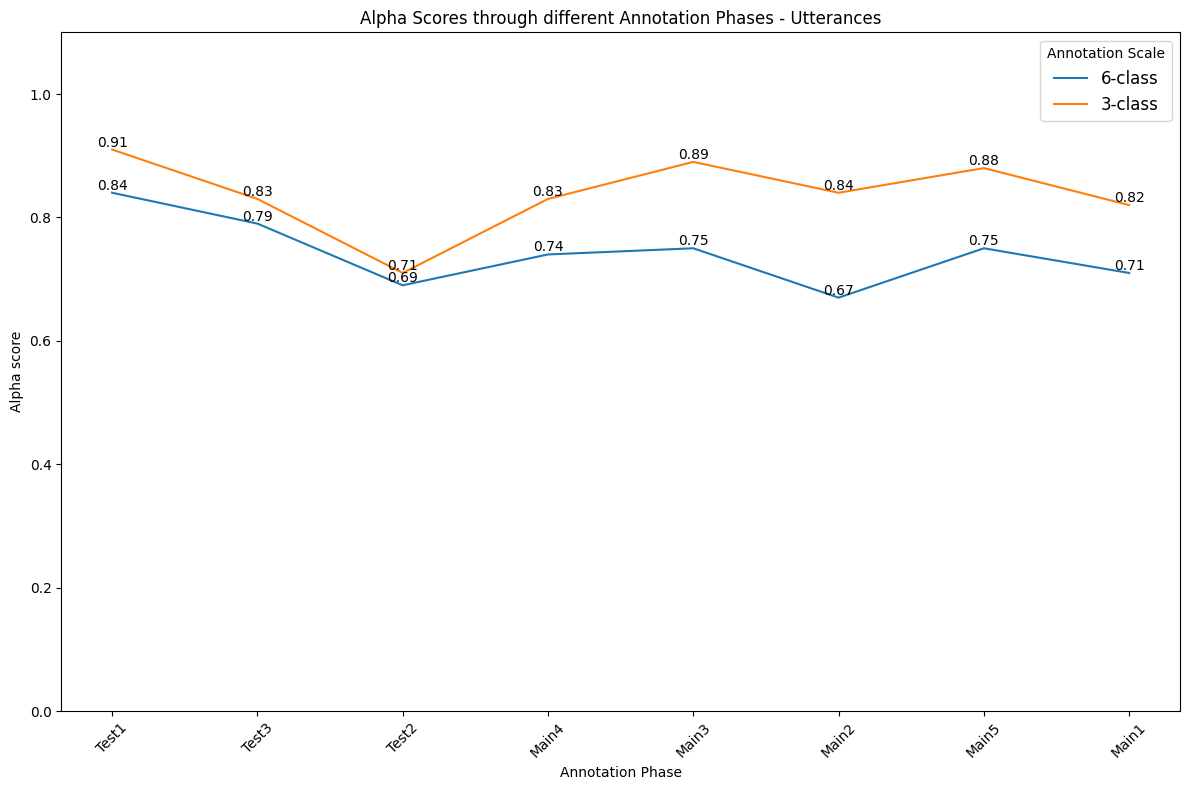

In [9]:
plt.figure(figsize=(12,8))
lineplot = sns.lineplot(data=scores, x="Phase", y="Alpha Score", hue='Scale', markers=True)

plt.title('Alpha Scores through different Annotation Phases - Utterances')
plt.xlabel("Annotation Phase")
plt.ylabel("Alpha score")
plt.legend(title="Annotation Scale", fontsize=12)
plt.xticks(rotation=45)
plt.ylim(0, 1.1)

for line in lineplot.lines:
    for x_data, y_data in zip(line.get_xdata(), line.get_ydata()):
        plt.text(x_data, y_data, f'{y_data:.2f}', fontsize=10, ha='center', va='bottom')

plt.tight_layout()
plt.savefig('../Figures/KA_Tracking.png', dpi=300)
plt.show()